**1. Set Up**

In [261]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

In [262]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score

In [263]:
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", lambda x:'{x:.3f}')
sns.set_theme(style='darkgrid')

RANDOM_STATE = 42
TARGET_COLUMN = "Outcome"

**2. Upload Data**

In [264]:
df = pd.read_csv("/content/sample_data/diabetes.csv")

In [265]:
df.shape

(768, 9)

In [266]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,{x:.3f},{x:.3f},50,1
1,1,85,66,29,0,{x:.3f},{x:.3f},31,0
2,8,183,64,0,0,{x:.3f},{x:.3f},32,1
3,1,89,66,23,94,{x:.3f},{x:.3f},21,0
4,0,137,40,35,168,{x:.3f},{x:.3f},33,1


**3. Exploratory Data Analysis**

In [267]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [268]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f}
mean,{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f}
std,{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f}
min,{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f}
25%,{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f}
50%,{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f}
75%,{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f}
max,{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f},{x:.3f}


In [269]:
# Basic Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Inference: No Categorical Columns and only Numerical Columns**

In [270]:
#  To understand if there are any encoded missing values such as 0
for col in df.columns:
  print(df[col].value_counts().head(10))

Pregnancies
1    135
0    111
2    103
3     75
4     68
5     57
6     50
7     45
8     38
9     28
Name: count, dtype: int64
Glucose
99     17
100    17
111    14
125    14
129    14
106    14
102    13
105    13
112    13
95     13
Name: count, dtype: int64
BloodPressure
70    57
74    52
78    45
68    45
72    44
64    43
80    40
76    39
60    37
0     35
Name: count, dtype: int64
SkinThickness
0     227
32     31
30     27
27     23
23     22
18     20
33     20
28     20
31     19
39     18
Name: count, dtype: int64
Insulin
0      374
105     11
130      9
140      9
120      8
94       7
180      7
100      7
110      6
115      6
Name: count, dtype: int64
BMI
{x:.3f}    13
{x:.3f}    12
{x:.3f}    12
{x:.3f}    11
{x:.3f}    10
{x:.3f}    10
{x:.3f}     9
{x:.3f}     9
{x:.3f}     9
{x:.3f}     9
Name: count, dtype: int64
DiabetesPedigreeFunction
{x:.3f}    6
{x:.3f}    6
{x:.3f}    5
{x:.3f}    5
{x:.3f}    5
{x:.3f}    5
{x:.3f}    5
{x:.3f}    4
{x:.3f}    4
{x:.3f}    4

**Inference: Columns - Pregnancies, SkinThickness, Insulin dont have missing values but have got 0 as values which needs to be replaces using appropriate imputation.**

In [271]:
duplicated_mask = df.duplicated()
num_of_duplicates = duplicated_mask.sum()

print("Number of duplicates: " , num_of_duplicates)
print("Duplicate Rows:", df[duplicated_mask])

Number of duplicates:  0
Duplicate Rows: Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [272]:
print(df[TARGET_COLUMN].value_counts())
print("-"*50)
print(df[TARGET_COLUMN].value_counts(normalize=True)*100)

Outcome
0    500
1    268
Name: count, dtype: int64
--------------------------------------------------
Outcome
0   {x:.3f}
1   {x:.3f}
Name: proportion, dtype: float64


**Inference: Data Imbalance is there.**

In [273]:
n_diab_count = (df[TARGET_COLUMN] == 1).sum()
n_nondiab_count = (df[TARGET_COLUMN] == 0).sum()

print("Imbalance Ratio:(Diabetic/Non-Diabetic): ", round(n_diab_count/max(n_nondiab_count,1),2))

Imbalance Ratio:(Diabetic/Non-Diabetic):  0.54


**Data Visualization**

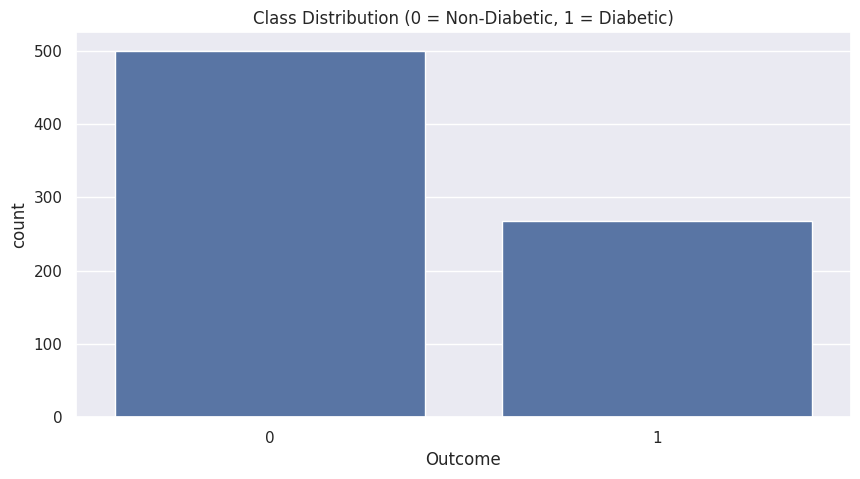

In [274]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x=TARGET_COLUMN)

plt.title("Class Distribution (0 = Non-Diabetic, 1 = Diabetic)")
plt.show()

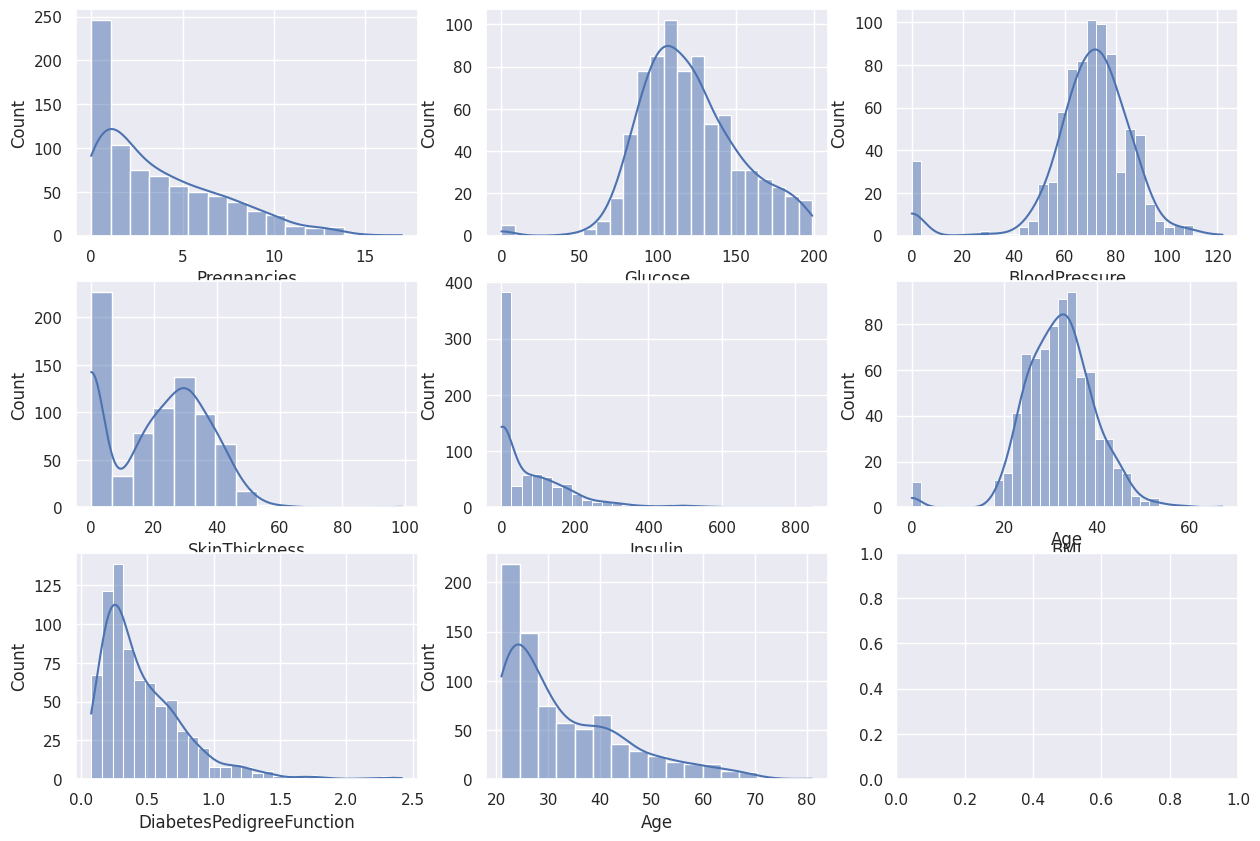

In [275]:
# histogram plot - distribution

fig, axes = plt.subplots(3, 3, figsize=(15,10))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
  sns.histplot(data=df, x=col, kde=True, ax=axes[i])
  plt.title(col)

plt.show()

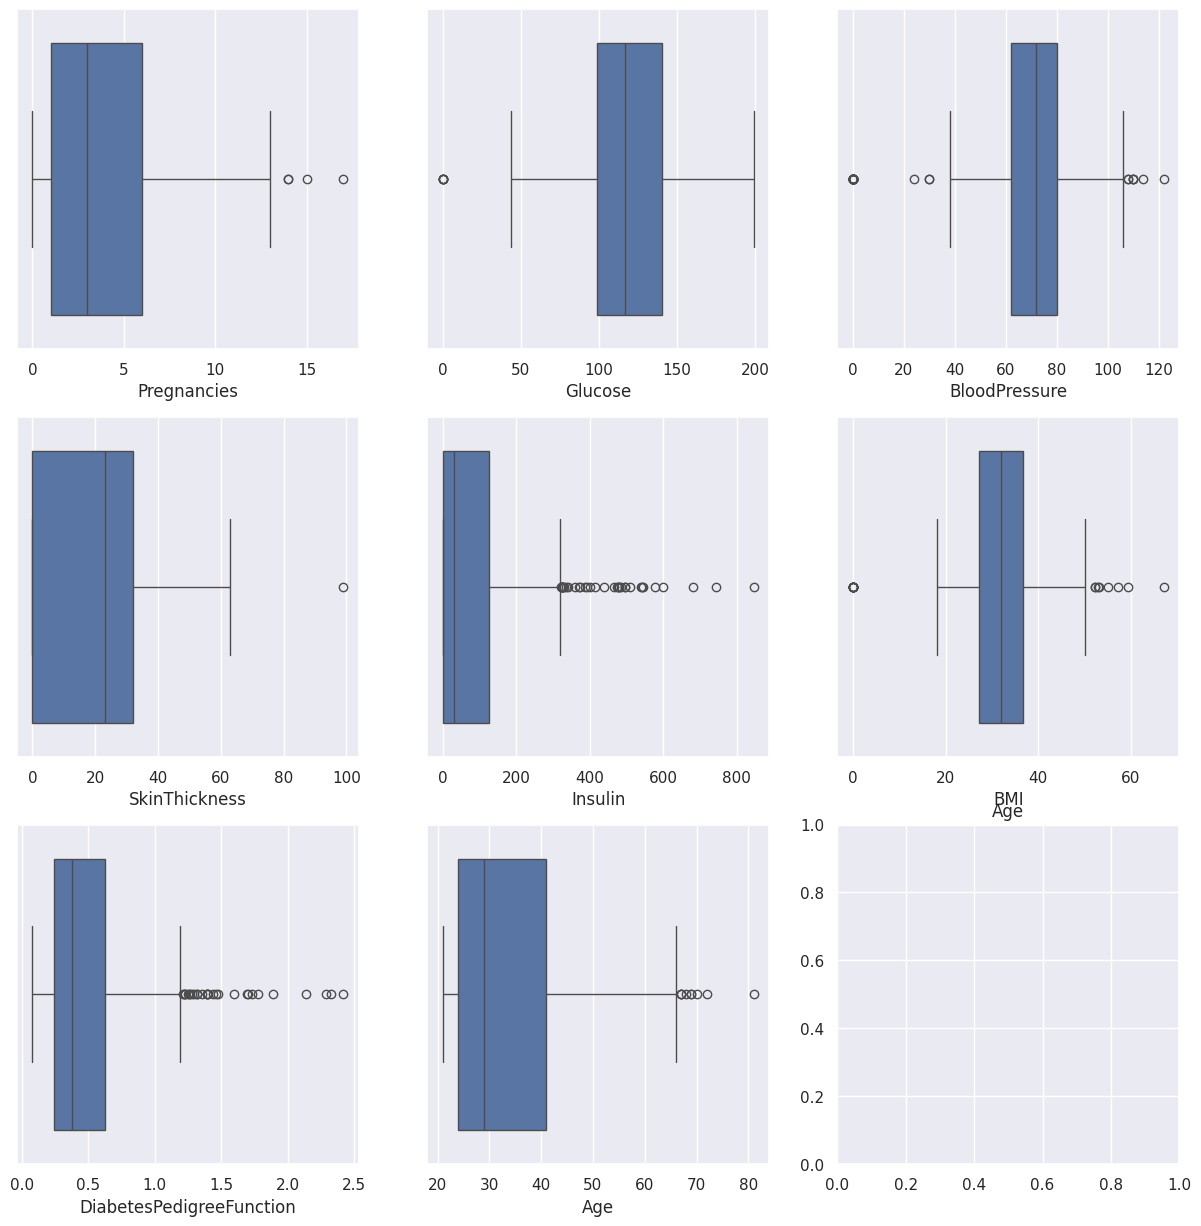

In [276]:
# Outlier Detection - Boxplot

fig, axes = plt.subplots(3, 3, figsize=(15,15))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
  sns.boxplot(data=df, x=col, ax=axes[i])
  plt.title(col)



plt.show()

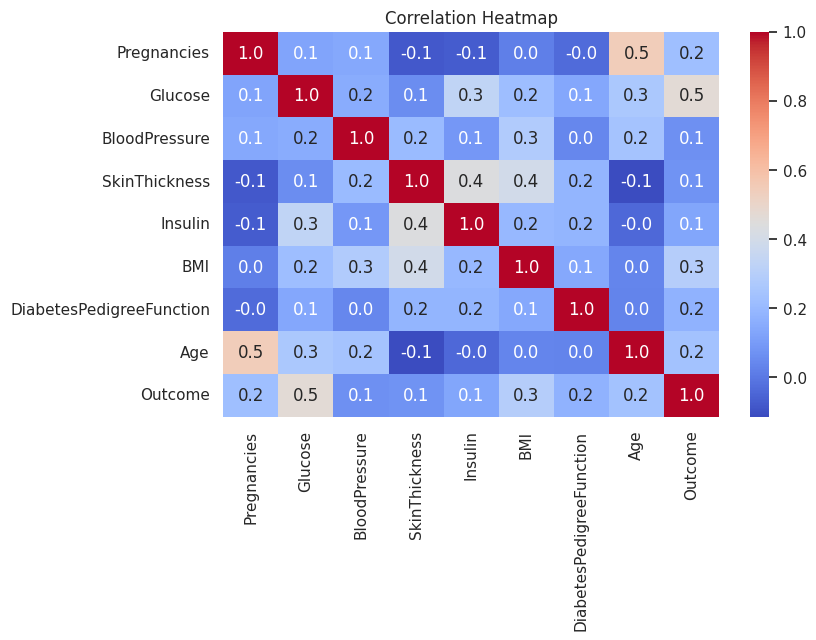

In [277]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(8, 5))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm',fmt='.1f')

plt.title("Correlation Heatmap")
plt.show()

**Not High Correlation**




**4. Data Preprocessing**

In [278]:
# separate data into features and target

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

In [279]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


In [280]:
print("Dataset size", X.shape)
print("Train Dataset size", X_train.shape)
print("Test Dataset size", X_test.shape)

Dataset size (768, 8)
Train Dataset size (614, 8)
Test Dataset size (154, 8)


**Preprocessing Pipeline**

In [281]:
cols_with_zeroes = ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()


def replace_zeros_with_nan_df(X, cols):
    """
    Replace 0 -> NaN for selected columns in a pandas DataFrame.
    Returns a NEW DataFrame (safe for sklearn pipelines).
    """
    X = X.copy()
    for col in cols:
        if col in X.columns:
            X[col] = X[col].replace(0, np.nan)
    return X

zero_to_nan = FunctionTransformer(replace_zeros_with_nan_df, kw_args={'cols': cols_with_zeroes}, validate = False)

numerical_tranformer = Pipeline(steps=[
    ("zero_to_nan", zero_to_nan),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(transformers=[
    ("numerical", numerical_tranformer, numerical_features)
])


**5. Baseline Model**

In [282]:
model_lr = LogisticRegression(random_state=RANDOM_STATE)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model_lr)
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('zero_to_nan',
                                                                   FunctionTransformer(func=<function replace_zeros_with_nan_df at 0x7de3f8cb2f20>,
                                                                                       kw_args={'cols': ['Pregnancies',
                                                                                                         'BloodPressure',
                                                                                                         'SkinThickness',
                                                                                                         'Insulin',
                                                                                                         'BMI']})),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age'])])),
                ('model', LogisticRegression(random_state=42))])

In [283]:
# reusable evaluation function

def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name):
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  # accuracy
  train_acc = accuracy_score(y_train, y_train_pred) * 100
  test_acc = accuracy_score(y_test, y_test_pred) * 100

  print("Training Accuracy: ", accuracy_score(y_train, y_train_pred))
  print("Testing Accuracy: ", accuracy_score(y_test, y_test_pred))    # results

  print(f"{model_name} - Train Accuracy: {train_acc:.2f}%")
  print(f"{model_name} - Test Accuracy: {test_acc:.2f}%\n")

  print("-"*40)

  print("Train Classification Report")
  print(classification_report(y_train, y_train_pred))

  print("-"*40)

  print("Test Classification Report")
  print(classification_report(y_test, y_test_pred))


In [284]:
evaluate_classifier(model_lr, X_train, y_train, X_test, y_test, "Logistic Regression")

Training Accuracy:  0.3485342019543974
Testing Accuracy:  0.35064935064935066
Logistic Regression - Train Accuracy: 34.85%
Logistic Regression - Test Accuracy: 35.06%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       400
           1       0.35      1.00      0.52       214

    accuracy                           0.35       614
   macro avg       0.17      0.50      0.26       614
weighted avg       0.12      0.35      0.18       614

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.52        54

    accuracy                           0.35       154
   macro avg       0.18      0.50      0.26       154
weighted avg       0.12      0.35      0.18       154



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr

**Lower Accuracy Score and Report for both train and test. LR performs poorly in identifying diabetic patients.**

**Model Selction and Optimization**

In [285]:
# scale_pos_weight = (# negative samples) / (# positive samples)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 1.8691588785046729


In [286]:
# models to try
models = { "LogisticRegression": Pipeline(
          [('preprocess', preprocess),
          ('model', LogisticRegression(random_state=RANDOM_STATE,
                class_weight='balanced',
                max_iter=1000))]),
           "SVC": Pipeline([('preprocess', preprocess),
                            ('model',SVC(random_state=RANDOM_STATE, class_weight='balanced'))]),
           "RandomForest": Pipeline([('preprocess', preprocess),
                                     ('model', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))]),
           "XGBoost": Pipeline(steps=[('preprocess',preprocess),
                                      ('model',XGBClassifier(random_state=RANDOM_STATE,scale_pos_weight=scale_pos_weight))])
           }

In [287]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [288]:
for name, model_pipeline in models.items():
  recall_scores=[]
  f1_scores=[]

  for tr_idx, te_idx in cv.split(X_train, y_train):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    model_pipeline.fit(X_tr, y_tr)
    y_pred = model_pipeline.predict(X_te)

    recall_scores.append(recall_score(y_te,y_pred))
    f1_scores.append(f1_score(y_te,y_pred))


  print("Model name:", name)
  print("Recall values:", recall_scores)
  print("F1 scores:", f1_scores)
  print("\nCV Recall mean:", round(float(np.mean(recall_scores)), 4))
  print("CV F1 Score mean:", round(float(np.mean(f1_scores)), 4))
  print("-"*50)

Model name: LogisticRegression
Recall values: [0.7209302325581395, 0.7674418604651163, 0.6744186046511628, 0.7209302325581395, 0.6904761904761905]
F1 scores: [0.6966292134831461, 0.6804123711340206, 0.6904761904761905, 0.6666666666666666, 0.6444444444444445]

CV Recall mean: 0.7148
CV F1 Score mean: 0.6757
--------------------------------------------------
Model name: SVC
Recall values: [0.7441860465116279, 0.7674418604651163, 0.7209302325581395, 0.7209302325581395, 0.7380952380952381]
F1 scores: [0.7191011235955056, 0.6534653465346535, 0.7294117647058823, 0.6526315789473685, 0.6391752577319587]

CV Recall mean: 0.7383
CV F1 Score mean: 0.6788
--------------------------------------------------
Model name: RandomForest
Recall values: [0.4883720930232558, 0.5813953488372093, 0.627906976744186, 0.627906976744186, 0.5714285714285714]
F1 scores: [0.5833333333333334, 0.6329113924050633, 0.7105263157894737, 0.6428571428571429, 0.6153846153846154]

CV Recall mean: 0.5794
CV F1 Score mean: 0.63

**NOTE: SVC (Support Vector Classifier) has better** **performance**

**Hyperparameter Tuning**

In [289]:
svc_opt = Pipeline(steps=[("preprocess", preprocess),("Support Vector Machine", SVC(random_state=RANDOM_STATE, class_weight="balanced"))])

In [290]:
param_grid_SVC = {
    'Support Vector Machine__C': [0.1, 1, 10, 100, 1000],
    'Support Vector Machine__gamma': ['scale', 0.001, 0.01, 0.1, 1]
}

In [291]:
# grid search

grid_search = GridSearchCV(estimator=svc_opt, param_grid = param_grid_SVC, scoring ="f1", cv=cv, verbose = True, n_jobs=-1)

In [292]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('zero_to_nan',
                                                                                          FunctionTransformer(func=<function replace_zeros_with_nan_df at 0x7de3f8cb2f20>,
                                                                                                              kw_args={'cols': ['Pregnancies',
                                                                                                                                'BloodPressure',
                                                                                                                                'SkinThickness',
                                                                                                                                'Insulin',
                                                                                                                                'BMI']})),
                                                                                         (...
                                                                                          StandardScaler())]),
                                                                         ['Pregnancies',
                                                                          'Glucose',
                                                                          'BloodPressure',
                                                                          'SkinThickness',
                                                                          'Insulin',
                                                                          'BMI',
                                                                          'DiabetesPedigreeFunction',
                                                                          'Age'])])),
                                       ('Support Vector Machine',
                                        SVC(class_weight='balanced',
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'Support Vector Machine__C': [0.1, 1, 10, 100, 1000],
                         'Support Vector Machine__gamma': ['scale', 0.001, 0.01,
                                                           0.1, 1]},
             scoring='f1', verbose=True)

In [293]:
print("Hyperparameter Tuning result:")
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Hyperparameter Tuning result:
Best params: {'Support Vector Machine__C': 1, 'Support Vector Machine__gamma': 'scale'}
Best score: 0.6787570143030737


**7. Retrain with best params**

In [294]:
best_pipeline_model = Pipeline([('preprocess', preprocess), ('model', SVC(random_state=RANDOM_STATE, class_weight='balanced', C=1,gamma='scale'))])

In [295]:
best_pipeline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('zero_to_nan',
                                                                   FunctionTransformer(func=<function replace_zeros_with_nan_df at 0x7de3f8cb2f20>,
                                                                                       kw_args={'cols': ['Pregnancies',
                                                                                                         'BloodPressure',
                                                                                                         'SkinThickness',
                                                                                                         'Insulin',
                                                                                                         'BMI']})),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age'])])),
                ('model', SVC(C=1, class_weight='balanced', random_state=42))])

In [296]:
evaluate_classifier(
    model=best_pipeline_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Best SVC"
)

Training Accuracy:  0.8127035830618893
Testing Accuracy:  0.7402597402597403
Best SVC - Train Accuracy: 81.27%
Best SVC - Test Accuracy: 74.03%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       400
           1       0.69      0.83      0.75       214

    accuracy                           0.81       614
   macro avg       0.80      0.82      0.80       614
weighted avg       0.83      0.81      0.82       614

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       100
           1       0.61      0.74      0.67        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.76      0.74      0.74       154



**9. Build a Predictive System**

In [297]:
def build_predictivesystem(input_features):
  input_df = pd.DataFrame([input_features], columns = X_train.columns)
  prediction = best_pipeline_model.predict(input_df)

  if prediction[0] == 1:
    return "Diabetic"
  else:
    return "Non-Diabetic"

In [298]:
X_test.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159,64,0,0,{x:.3f},{x:.3f},40
672,10,68,106,23,49,{x:.3f},{x:.3f},47
700,2,122,76,27,200,{x:.3f},{x:.3f},26
630,7,114,64,0,0,{x:.3f},{x:.3f},34
81,2,74,0,0,0,{x:.3f},{x:.3f},22


In [299]:
y_test.head()

,Outcome
44,0
672,0
700,0
630,1
81,0


In [300]:
# sample unknown data point - access from test data index

test_1 = X_test.loc[700].tolist()
test_1

[2.0, 122.0, 76.0, 27.0, 200.0, 35.9, 0.483, 26.0]

In [301]:
y_test.loc[700]

np.int64(0)

In [302]:
build_predictivesystem(test_1)

'Non-Diabetic'

In [303]:
test_2 = X_test.loc[630].tolist()
test_2

[7.0, 114.0, 64.0, 0.0, 0.0, 27.4, 0.732, 34.0]

In [304]:
y_test.loc[630]

np.int64(1)

In [305]:
build_predictivesystem(test_2)

'Diabetic'

**Important Note:** This is a strong and realistic performance for this dataset. Even with correct preprocessing, cross-validation, and model tuning, some predictions will still be wrong. No model can achieve 100% accuracy on this problem because the dataset itself has overlapping patterns and noise, which creates a natural performance ceiling. While further improvements are possible through advanced techniques, this result is a solid and trustworthy stopping point for our current approach.